# Phân loại Cử chỉ Nhắm/Mở Mắt với Keras và MobileNet

Tệp lệnh này được điều chỉnh cho bộ dữ liệu **Open/Closed Eyes Dataset** của *sehriyarmemmedli*. Cấu trúc tự nhiên của nó (thư mục Open, Closed riêng biệt) cho phép chúng ta tải thẳng vào model một cách cực kỳ tối ưu bộ nhớ.

Sau khi hoàn thành, đoạn script sẽ xuất ra một tệp con lai `mobilenet_eye_blink.onnx` để ứng dụng trực tiếp trên con backend FastAPI cho đồ án môn.

## Bước 1: Tiền xử lý Dữ Liệu
Giải nén nội dung Kaggle vừa tải về vào ngay trong thư mục: `dataset/eye-dataset/`.
Lúc đó, bạn sẽ có các thư mục con như `dataset/eye-dataset/Open/` và `dataset/eye-dataset/Closed/`.
Ta sẽ dùng `image_dataset_from_directory` tiện lợi của Keras để chia batch và scale.

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

DATASET_PATH = "dataset/eye-dataset/"  # Thư mục chứa 3 thư mục train, val, test
IMG_SIZE = 80             # Scale mắt về con số này
BATCH_SIZE = 64

# 1. Load tập Training
train_ds = tf.keras.utils.image_dataset_from_directory(
  os.path.join(DATASET_PATH, 'train'),
  seed=42,
  image_size=(IMG_SIZE, IMG_SIZE),
  batch_size=BATCH_SIZE)

# 2. Load tập Validation
val_ds = tf.keras.utils.image_dataset_from_directory(
  os.path.join(DATASET_PATH, 'val'),
  seed=42,
  image_size=(IMG_SIZE, IMG_SIZE),
  batch_size=BATCH_SIZE)

# 3. Load tập Test
test_ds = tf.keras.utils.image_dataset_from_directory(
  os.path.join(DATASET_PATH, 'test'),
  seed=42,
  image_size=(IMG_SIZE, IMG_SIZE),
  batch_size=BATCH_SIZE)

class_names = train_ds.class_names
print(f"\nDanh sách nhãn được Keras tự phát hiện: {class_names}")
# Thông thường nếu tên thư mục là Closed và Open, Keras sẽ gán theo chữ cái: Closed=0, Open=1


Found 139804 files belonging to 2 classes.
Found 27961 files belonging to 2 classes.
Found 6991 files belonging to 2 classes.

Danh sách nhãn được Keras tự phát hiện: ['closed', 'open']


Vì MobileNet cần phổ đầu vào từ -1 đến 1 (hoặc chuẩn hoá Rescaling), chúng ta định nghĩa hẳn một pipeline cache dữ liệu hiệu năng cao.

In [2]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))


## Bước 2: Load Kiến trúc MobileNetV2

In [3]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.optimizers import Adam

# Transfer Learning: Đóng gói base
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

# Mở đóng băng 20 layers cuối để nó học các nét tinh tế của "Lông mi" và "Lòng đen"
for layer in base_model.layers[-20:]:
    layer.trainable = True

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False) # Gọi base
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(32, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x) # sigmoid vì output là binary: 0 hoặc 1

model = Model(inputs, outputs)

model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/var/folders/rx/h8y4kb4d22v0m9vmyr2rv5sr0000gn/T/ipykernel_7266/2079391004.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 80, 80, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        40,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,299,009 (8.77 MB)

 Trainable params: 1,247,105 (4.76 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

## Bước 3: Tiến hành Training Model

In [4]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_blink_mobilenet.h5", save_best_only=True)

EPOCHS = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
2184/2185 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9468 - loss: 0.1286

2185/2185 ━━━━━━━━━━━━━━━━━━━━ 159s 71ms/step - accuracy: 0.9685 - loss: 0.0820 - val_accuracy: 0.9810 - val_loss: 0.0563
Epoch 2/10
2184/2185 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9827 - loss: 0.0459

2185/2185 ━━━━━━━━━━━━━━━━━━━━ 150s 69ms/step - accuracy: 0.9844 - loss: 0.0406 - val_accuracy: 0.9843 - val_loss: 0.0470
Epoch 3/10
2185/2185 ━━━━━━━━━━━━━━━━━━━━ 150s 68ms/step - accuracy: 0.9896 - loss: 0.0272 - val_accuracy: 0.9835 - val_loss: 0.0533
Epoch 4/10
2185/2185 ━━━━━━━━━━━━━━━━━━━━ 149s 68ms/step - accuracy: 0.9929 - loss: 0.0185 - val_accuracy: 0.9848 - val_loss: 0.0550
Epoch 5/10
2185/2185 ━━━━━━━━━━━━━━━━━━━━ 151s 69ms/step - accuracy: 0.9948 - loss: 0.0138 - val_accuracy: 0.9856 - val_loss: 0.0657
Epoch 6/10
2185/2185 ━━━━━━━━━━━━━━━━━━━━ 152s 69ms/step - accuracy: 0.9959 - loss: 0.0117 - val_accuracy: 0.9862 - val_loss: 0.0679


## Bước 4: Đánh giá Trực quan

110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.9848 - loss: 0.0469

Độ chính xác (Accuracy) cuối cùng trên tập Test: 98.48%


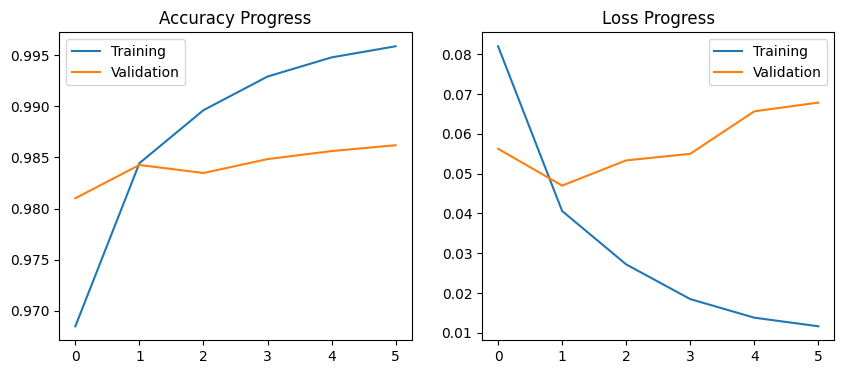

In [5]:
loss, acc = model.evaluate(test_ds)
print(f"\nĐộ chính xác (Accuracy) cuối cùng trên tập Test: {acc*100:.2f}%")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy Progress')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss Progress')
plt.legend()
plt.show()

## Step 5: ONNX Export

In [6]:
!pip install -q tf2onnx
import tf2onnx

spec = (tf.TensorSpec((None, IMG_SIZE, IMG_SIZE, 3), tf.float32, name="input"),)
output_path = "mobilenet_eye_blink.onnx"

model_proto, _ = tf2onnx.convert.from_keras(model, input_signature=spec, opset=13, output_path=output_path)
output_names = [n.name for n in model_proto.graph.output]
print(f"\nTrích xuất ONNX thành công! Tên gốc file: {output_path}")
print(f"Ghi chú lại Tên Input: input, Tên Output: {output_names}")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 3.20.3 which is incompatible.


I0000 00:00:1776019282.840899   53753 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1776019282.841005   53753 single_machine.cc:376] Starting new session
I0000 00:00:1776019283.269261   53753 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1776019283.269331   53753 single_machine.cc:376] Starting new session



Trích xuất ONNX thành công! Tên gốc file: mobilenet_eye_blink.onnx
Ghi chú lại Tên Input: input, Tên Output: ['dense_1']
